INSTALLING REQUIRED LIBRARIES
Installation complete.

ENVIRONMENT
Ultralytics: 8.4.164
PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4

Project folders created.

LOCATING SAMPLE IMAGE
Ultralytics location: /usr/local/lib/python3.13/dist-packages/ultralytics
Images found: 2
Using sample image: /usr/local/lib/python3.13/dist-packages/ultralytics/assets/zidane.jpg

VERIFYING IMAGE
Image verified successfully.
Image shape: (720, 1280, 3)


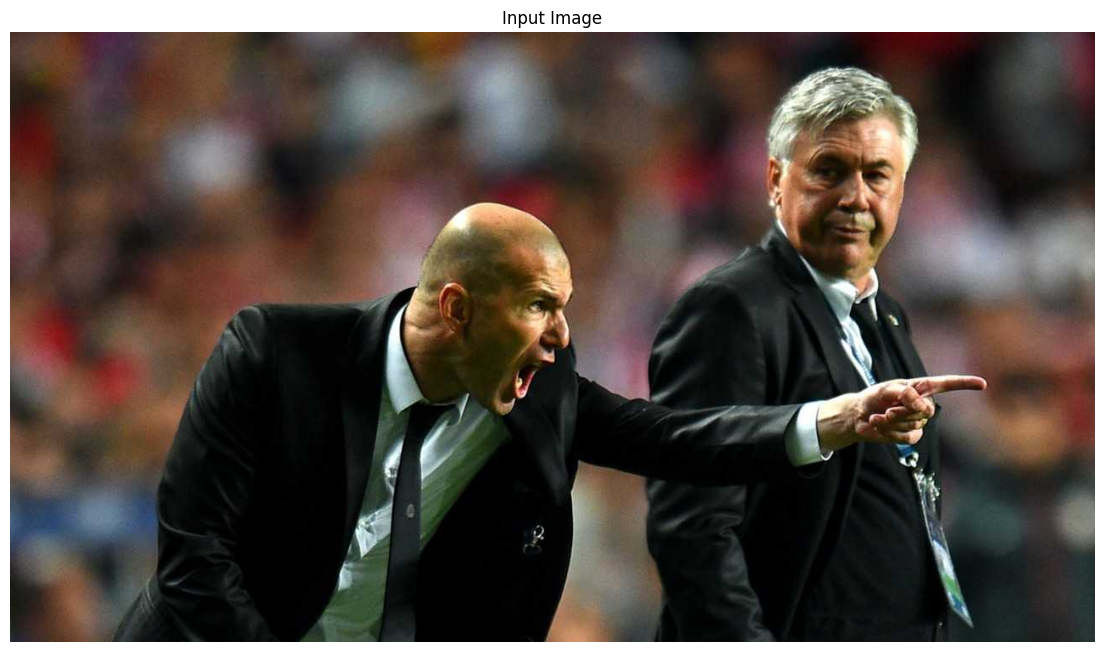


LOADING YOLO
Loaded: yolo11n.pt

RUNNING OBJECT DETECTION
Inference time: 6.5586 seconds
Saved: /content/YOLO-Autonomous-Vehicle/output/detected_objects.jpg


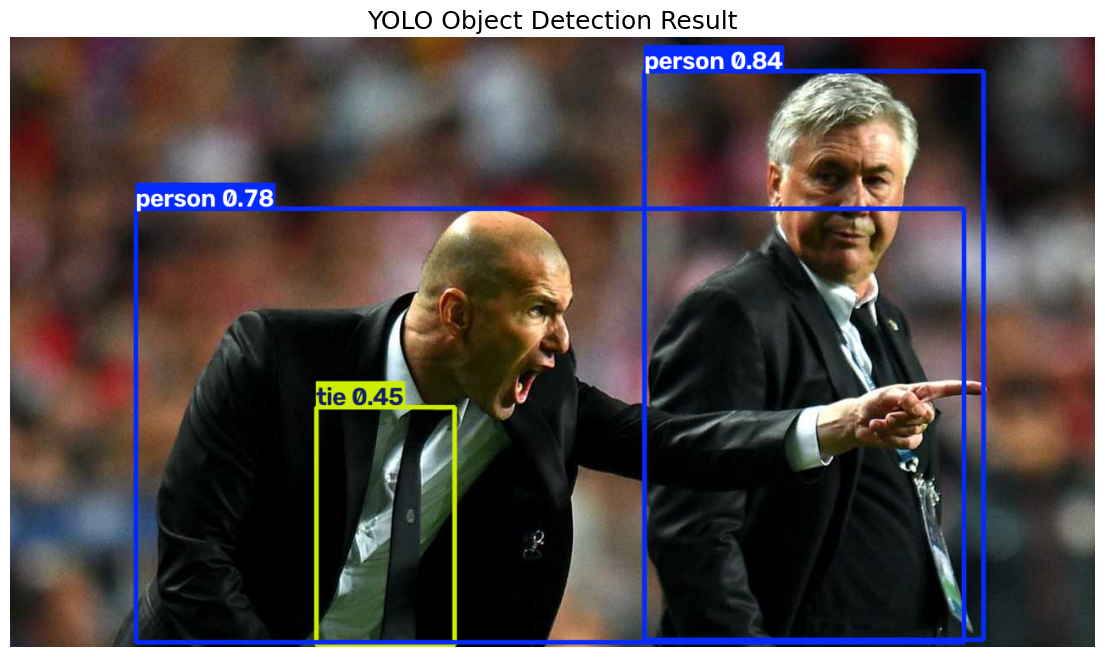


DETECTED OBJECTS
person              0.840
person              0.779
tie                 0.452

Detection CSV: /content/YOLO-Autonomous-Vehicle/results/detection_results.csv


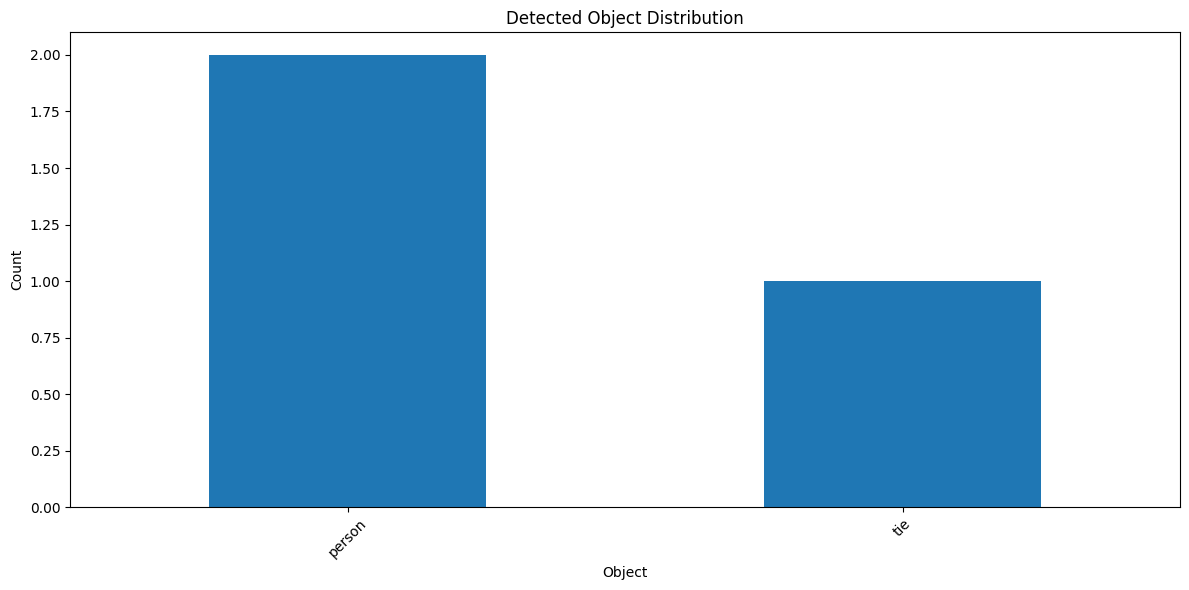

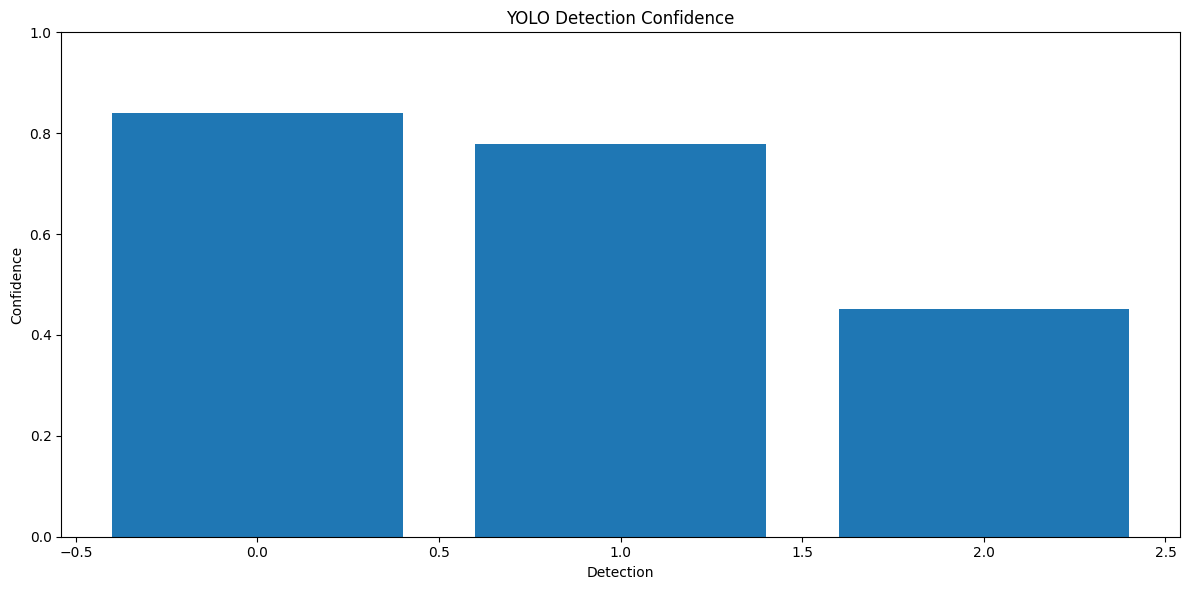


PERFORMANCE TEST


Inference tests:   0%|          | 0/20 [00:00<?, ?it/s]


PERFORMANCE RESULTS
Tests: 20
Average inference: 0.0202 sec
Minimum inference: 0.0184 sec
Maximum inference: 0.0249 sec
Standard deviation: 0.0016 sec
Approximate FPS: 49.53


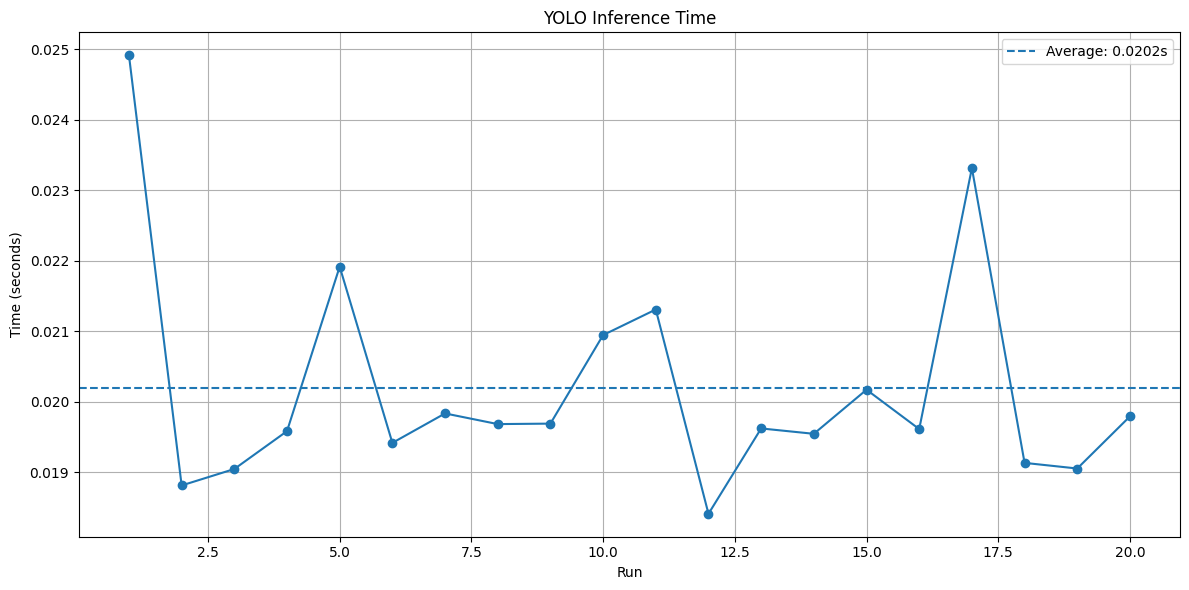

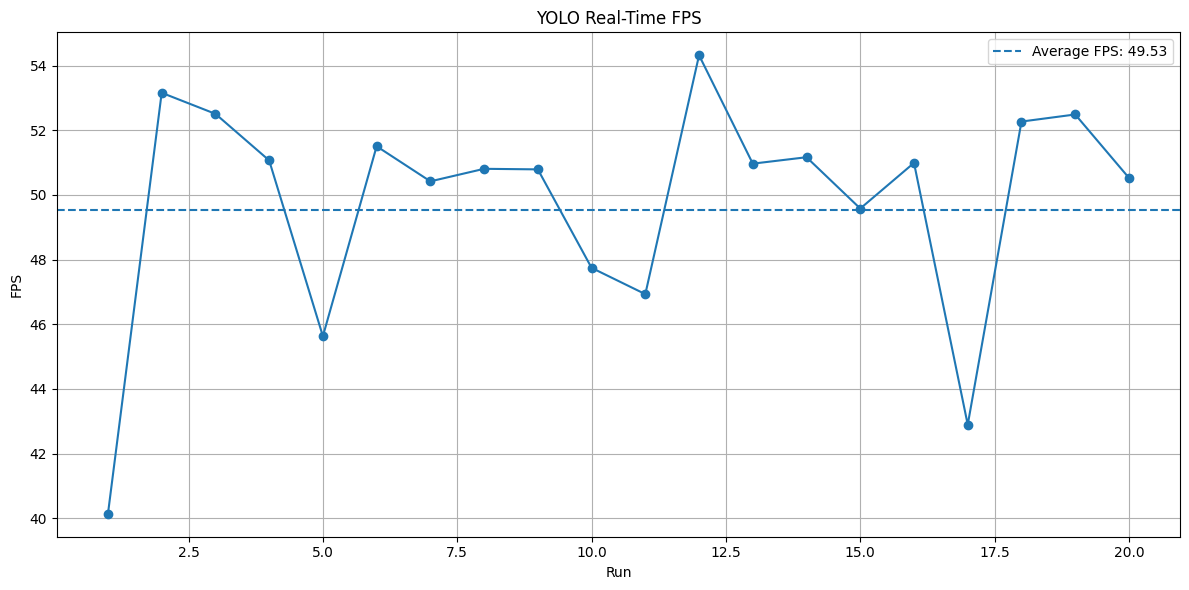


Performance summary:


,Metric,Value
0,YOLO Model,yolo11n.pt
1,Hardware,Tesla T4
2,Image Resolution,640 x 640
3,Confidence Threshold,0.25
4,Tests,20
5,Average Inference Time,0.0202
6,Minimum Inference Time,0.0184
7,Maximum Inference Time,0.0249
8,Standard Deviation,0.0016
9,Average FPS,49.53



PROJECT STRUCTURE
YOLO-Autonomous-Vehicle/
    .gitignore
    README.md
    requirements.txt
    src/
        detect_image.py
    report/
    results/
        project_summary.txt
        performance_summary.csv
        performance_results.csv
        detection_results.csv
        graphs/
            confidence_scores.png
            inference_time.png
            object_distribution.png
            fps_performance.png
    input/
        sample_vehicle_scene.jpg
    output/
        detected_objects.jpg

CREATING ZIP
ZIP created:
/content/YOLO-Autonomous-Vehicle-Project.zip


PROJECT COMPLETED SUCCESSFULLY
YOLO Model       : yolo11n.pt
GPU              : Tesla T4
Detections       : 3
Average Time     : 0.0202 sec
Average FPS      : 49.53
Project Folder   : /content/YOLO-Autonomous-Vehicle
ZIP              : /content/YOLO-Autonomous-Vehicle-Project.zip
NEXT: DOWNLOAD ZIP AND PUSH TO GITHUB


In [4]:
# ================================================================
# YOLO AUTONOMOUS VEHICLE PROJECT
# CLEAN + INTERNET-INDEPENDENT VERSION
# ================================================================

import os
import sys
import cv2
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

# ================================================================
# 1. INSTALL
# ================================================================

print("=" * 70)
print("INSTALLING REQUIRED LIBRARIES")
print("=" * 70)

os.system(
    "pip install -q ultralytics opencv-python matplotlib pandas numpy pillow tqdm"
)

print("Installation complete.")


# ================================================================
# 2. IMPORT YOLO
# ================================================================

import torch
import ultralytics

from ultralytics import YOLO

print("\n" + "=" * 70)
print("ENVIRONMENT")
print("=" * 70)

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():

    DEVICE = 0

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    DEVICE = "cpu"

    print("GPU unavailable. Using CPU.")


# ================================================================
# 3. CREATE CLEAN PROJECT
# ================================================================

PROJECT = Path(
    "/content/YOLO-Autonomous-Vehicle"
)

if PROJECT.exists():

    shutil.rmtree(
        PROJECT
    )

INPUT = PROJECT / "input"
OUTPUT = PROJECT / "output"
RESULTS = PROJECT / "results"
GRAPHS = RESULTS / "graphs"
SRC = PROJECT / "src"
REPORT = PROJECT / "report"

for folder in [
    INPUT,
    OUTPUT,
    RESULTS,
    GRAPHS,
    SRC,
    REPORT
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("\nProject folders created.")


# ================================================================
# 4. FIND ULTRALYTICS SAMPLE IMAGE
# ================================================================

print("\n" + "=" * 70)
print("LOCATING SAMPLE IMAGE")
print("=" * 70)

import ultralytics

ultra_path = Path(
    ultralytics.__file__
).parent

print(
    "Ultralytics location:",
    ultra_path
)

# Search for jpg/jpeg/png images
image_candidates = []

for extension in [
    "*.jpg",
    "*.jpeg",
    "*.png"
]:

    image_candidates.extend(
        ultra_path.rglob(extension)
    )

print(
    "Images found:",
    len(image_candidates)
)


# ================================================================
# 5. IF PACKAGE HAS IMAGE, USE IT
# ================================================================

sample_image = None

for candidate in image_candidates:

    try:

        img = cv2.imread(
            str(candidate)
        )

        if img is not None:

            sample_image = candidate

            print(
                "Using sample image:",
                candidate
            )

            break

    except Exception:
        pass


# ================================================================
# 6. FALLBACK: CREATE SYNTHETIC TEST IMAGE
# ================================================================

if sample_image is None:

    print(
        "\nNo package image found."
    )

    print(
        "Creating local test image..."
    )

    img = np.zeros(
        (720, 1280, 3),
        dtype=np.uint8
    )

    # Sky
    img[
        0:450,
        :
    ] = (
        180,
        210,
        240
    )

    # Road
    img[
        450:720,
        :
    ] = (
        70,
        70,
        70
    )

    # Lane markings

    for x in range(
        100,
        1200,
        220
    ):

        cv2.line(
            img,
            (x, 720),
            (x + 100, 450),
            (255, 255, 255),
            8
        )

    # Cars

    car_positions = [
        (200, 520),
        (600, 500),
        (950, 540)
    ]

    for x, y in car_positions:

        # body
        cv2.rectangle(
            img,
            (x, y),
            (x + 180, y + 90),
            (30, 40, 180),
            -1
        )

        # windows
        cv2.rectangle(
            img,
            (x + 35, y - 45),
            (x + 145, y + 5),
            (100, 150, 190),
            -1
        )

        # wheels
        cv2.circle(
            img,
            (x + 40, y + 95),
            25,
            (20, 20, 20),
            -1
        )

        cv2.circle(
            img,
            (x + 140, y + 95),
            25,
            (20, 20, 20),
            -1
        )

    # Title

    cv2.putText(
        img,
        "AUTONOMOUS VEHICLE TEST SCENE",
        (280, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (0, 0, 0),
        3
    )

    sample_image = INPUT / "sample_vehicle_scene.jpg"

    cv2.imwrite(
        str(sample_image),
        img
    )

else:

    sample_image = INPUT / "sample_vehicle_scene.jpg"

    shutil.copy(
        str(
            image_candidates[0]
        ),
        str(sample_image)
    )


# ================================================================
# 7. VERIFY IMAGE
# ================================================================

print("\n" + "=" * 70)
print("VERIFYING IMAGE")
print("=" * 70)

if not sample_image.exists():

    raise RuntimeError(
        "ERROR: Sample image was not created."
    )

test_img = cv2.imread(
    str(sample_image)
)

if test_img is None:

    raise RuntimeError(
        "ERROR: OpenCV could not read the image."
    )

print(
    "Image verified successfully."
)

print(
    "Image shape:",
    test_img.shape
)


# ================================================================
# 8. DISPLAY INPUT
# ================================================================

plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    cv2.cvtColor(
        test_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Input Image"
)

plt.axis(
    "off"
)

plt.show()


# ================================================================
# 9. LOAD YOLO
# ================================================================

print("\n" + "=" * 70)
print("LOADING YOLO")
print("=" * 70)

MODEL_NAME = "yolo11n.pt"

model = YOLO(
    MODEL_NAME
)

print(
    "Loaded:",
    MODEL_NAME
)


# ================================================================
# 10. IMAGE DETECTION
# ================================================================

print("\n" + "=" * 70)
print("RUNNING OBJECT DETECTION")
print("=" * 70)

start = time.perf_counter()

prediction = model.predict(
    source=str(sample_image),
    device=DEVICE,
    imgsz=640,
    conf=0.25,
    verbose=False
)

end = time.perf_counter()

first_inference = end - start

result = prediction[0]

print(
    f"Inference time: "
    f"{first_inference:.4f} seconds"
)


# ================================================================
# 11. SAVE RESULT
# ================================================================

annotated = result.plot()

output_image = (
    OUTPUT /
    "detected_objects.jpg"
)

cv2.imwrite(
    str(output_image),
    annotated
)

print(
    "Saved:",
    output_image
)


# ================================================================
# 12. DISPLAY RESULT
# ================================================================

plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "YOLO Object Detection Result",
    fontsize=18
)

plt.axis(
    "off"
)

plt.show()


# ================================================================
# 13. EXTRACT OBJECTS
# ================================================================

print("\n" + "=" * 70)
print("DETECTED OBJECTS")
print("=" * 70)

detections = []

if result.boxes is not None:

    for i in range(
        len(result.boxes)
    ):

        class_id = int(
            result.boxes.cls[i].item()
        )

        confidence = float(
            result.boxes.conf[i].item()
        )

        name = model.names[
            class_id
        ]

        detections.append({

            "Object": name,

            "Confidence": confidence

        })

        print(
            f"{name:<20}"
            f"{confidence:.3f}"
        )

else:

    print(
        "No objects detected."
    )


# ================================================================
# 14. SAVE DETECTION DATA
# ================================================================

detection_df = pd.DataFrame(
    detections
)

detection_csv = (
    RESULTS /
    "detection_results.csv"
)

detection_df.to_csv(
    str(detection_csv),
    index=False
)

print(
    "\nDetection CSV:",
    detection_csv
)


# ================================================================
# 15. OBJECT DISTRIBUTION
# ================================================================

if len(detection_df) > 0:

    counts = (
        detection_df[
            "Object"
        ]
        .value_counts()
    )

    plt.figure(
        figsize=(12, 6)
    )

    counts.plot(
        kind="bar"
    )

    plt.title(
        "Detected Object Distribution"
    )

    plt.xlabel(
        "Object"
    )

    plt.ylabel(
        "Count"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        str(
            GRAPHS /
            "object_distribution.png"
        ),
        dpi=300
    )

    plt.show()


# ================================================================
# 16. CONFIDENCE GRAPH
# ================================================================

if len(detection_df) > 0:

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        range(
            len(detection_df)
        ),
        detection_df[
            "Confidence"
        ]
    )

    plt.title(
        "YOLO Detection Confidence"
    )

    plt.xlabel(
        "Detection"
    )

    plt.ylabel(
        "Confidence"
    )

    plt.ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.savefig(
        str(
            GRAPHS /
            "confidence_scores.png"
        ),
        dpi=300
    )

    plt.show()


# ================================================================
# 17. PERFORMANCE TEST
# ================================================================

print("\n" + "=" * 70)
print("PERFORMANCE TEST")
print("=" * 70)

RUNS = 20

times = []

for _ in tqdm(
    range(RUNS),
    desc="Inference tests"
):

    start = time.perf_counter()

    model.predict(
        source=str(sample_image),
        device=DEVICE,
        imgsz=640,
        conf=0.25,
        verbose=False
    )

    end = time.perf_counter()

    times.append(
        end - start
    )


times = np.array(
    times
)

average_time = times.mean()
minimum_time = times.min()
maximum_time = times.max()
std_time = times.std()

fps = 1 / average_time


# ================================================================
# 18. PRINT PERFORMANCE
# ================================================================

print("\n" + "=" * 70)
print("PERFORMANCE RESULTS")
print("=" * 70)

print(
    "Tests:",
    RUNS
)

print(
    f"Average inference: "
    f"{average_time:.4f} sec"
)

print(
    f"Minimum inference: "
    f"{minimum_time:.4f} sec"
)

print(
    f"Maximum inference: "
    f"{maximum_time:.4f} sec"
)

print(
    f"Standard deviation: "
    f"{std_time:.4f} sec"
)

print(
    f"Approximate FPS: "
    f"{fps:.2f}"
)


# ================================================================
# 19. PERFORMANCE DATA
# ================================================================

performance = pd.DataFrame({

    "Run": range(
        1,
        RUNS + 1
    ),

    "Inference_Time": times,

    "FPS": 1 / times
})

performance.to_csv(
    str(
        RESULTS /
        "performance_results.csv"
    ),
    index=False
)


# ================================================================
# 20. INFERENCE TIME GRAPH
# ================================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    performance["Run"],
    performance[
        "Inference_Time"
    ],
    marker="o"
)

plt.axhline(
    average_time,
    linestyle="--",
    label=(
        f"Average: "
        f"{average_time:.4f}s"
    )
)

plt.title(
    "YOLO Inference Time"
)

plt.xlabel(
    "Run"
)

plt.ylabel(
    "Time (seconds)"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.savefig(
    str(
        GRAPHS /
        "inference_time.png"
    ),
    dpi=300
)

plt.show()


# ================================================================
# 21. FPS GRAPH
# ================================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    performance["Run"],
    performance["FPS"],
    marker="o"
)

plt.axhline(
    fps,
    linestyle="--",
    label=(
        f"Average FPS: "
        f"{fps:.2f}"
    )
)

plt.title(
    "YOLO Real-Time FPS"
)

plt.xlabel(
    "Run"
)

plt.ylabel(
    "FPS"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.savefig(
    str(
        GRAPHS /
        "fps_performance.png"
    ),
    dpi=300
)

plt.show()


# ================================================================
# 22. PERFORMANCE SUMMARY CSV
# ================================================================

summary = pd.DataFrame({

    "Metric": [

        "YOLO Model",

        "Hardware",

        "Image Resolution",

        "Confidence Threshold",

        "Tests",

        "Average Inference Time",

        "Minimum Inference Time",

        "Maximum Inference Time",

        "Standard Deviation",

        "Average FPS"

    ],

    "Value": [

        MODEL_NAME,

        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "CPU"
        ),

        "640 x 640",

        0.25,

        RUNS,

        round(
            average_time,
            4
        ),

        round(
            minimum_time,
            4
        ),

        round(
            maximum_time,
            4
        ),

        round(
            std_time,
            4
        ),

        round(
            fps,
            2
        )

    ]

})

summary.to_csv(
    str(
        RESULTS /
        "performance_summary.csv"
    ),
    index=False
)

print("\nPerformance summary:")
display(summary)


# ================================================================
# 23. REQUIREMENTS.TXT
# ================================================================

requirements = """ultralytics
opencv-python
matplotlib
pandas
numpy
pillow
tqdm
torch
torchvision
"""

with open(
    PROJECT /
    "requirements.txt",
    "w"
) as f:

    f.write(
        requirements
    )


# ================================================================
# 24. GITIGNORE
# ================================================================

gitignore = """__pycache__/
*.pyc
.ipynb_checkpoints/
.env
.venv/
venv/
*.log
*.pt
"""

with open(
    PROJECT /
    ".gitignore",
    "w"
) as f:

    f.write(
        gitignore
    )


# ================================================================
# 25. README
# ================================================================

readme = f"""# Analysis of Real-Time Object Detection Using YOLO

## Module 2 - Autonomous Vehicles

### Overview

This project implements and analyzes YOLO-based real-time
object detection for autonomous vehicle perception.

### Objectives

- Detect objects using YOLO.
- Analyze confidence scores.
- Measure inference time.
- Calculate approximate FPS.
- Visualize detection results.
- Analyze the suitability of YOLO for real-time applications.

### Technologies

- Python
- Google Colab
- YOLO
- Ultralytics
- OpenCV
- PyTorch
- NumPy
- Pandas
- Matplotlib

### Model

{MODEL_NAME}

### Hardware

{torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}

### Experimental Results

Average inference time:

{average_time:.4f} seconds

Approximate FPS:

{fps:.2f}

### Project Structure

YOLO-Autonomous-Vehicle/

- input/
- output/
- results/
- results/graphs/
- src/
- report/
- README.md
- requirements.txt
- .gitignore

### Autonomous Vehicle Relevance

Object detection forms an important part of an autonomous
vehicle perception pipeline. Camera-based object detection
can identify surrounding vehicles, pedestrians and other
objects.

Low inference latency is important for real-time perception.

### Future Improvements

- Compare YOLO model variants.
- Evaluate precision, recall and mAP.
- Use autonomous-driving datasets.
- Add video detection.
- Integrate LiDAR and camera data.
- Deploy on embedded automotive hardware.
"""

with open(
    PROJECT /
    "README.md",
    "w"
) as f:

    f.write(
        readme
    )


# ================================================================
# 26. SOURCE CODE
# ================================================================

source_code = """from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.predict(
    source="../input/sample_vehicle_scene.jpg",
    conf=0.25,
    save=True
)

print("Detection completed.")
"""

with open(
    SRC /
    "detect_image.py",
    "w"
) as f:

    f.write(
        source_code
    )


# ================================================================
# 27. PROJECT SUMMARY
# ================================================================

project_summary = f"""YOLO AUTONOMOUS VEHICLE PROJECT

Model: {MODEL_NAME}

Hardware: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}

Number of detections: {len(detection_df)}

Average inference time: {average_time:.4f} seconds

Approximate FPS: {fps:.2f}

Minimum inference time: {minimum_time:.4f} seconds

Maximum inference time: {maximum_time:.4f} seconds

Standard deviation: {std_time:.4f} seconds
"""

with open(
    RESULTS /
    "project_summary.txt",
    "w"
) as f:

    f.write(
        project_summary
    )


# ================================================================
# 28. PROJECT STRUCTURE
# ================================================================

print("\n" + "=" * 70)
print("PROJECT STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk(
    PROJECT
):

    level = root.replace(
        str(PROJECT),
        ""
    ).count(
        os.sep
    )

    indent = (
        "    " *
        level
    )

    print(
        indent +
        os.path.basename(root) +
        "/"
    )

    for filename in files:

        print(
            "    " *
            (level + 1) +
            filename
        )


# ================================================================
# 29. CREATE ZIP
# ================================================================

print("\n" + "=" * 70)
print("CREATING ZIP")
print("=" * 70)

zip_base = (
    "/content/"
    "YOLO-Autonomous-Vehicle-Project"
)

if os.path.exists(
    zip_base + ".zip"
):

    os.remove(
        zip_base + ".zip"
    )

shutil.make_archive(
    zip_base,
    "zip",
    str(PROJECT)
)

print(
    "ZIP created:"
)

print(
    zip_base + ".zip"
)


# ================================================================
# 30. FINAL
# ================================================================

print("\n")
print("=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"YOLO Model       : {MODEL_NAME}"
)

print(
    f"GPU              : "
    f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}"
)

print(
    f"Detections       : {len(detection_df)}"
)

print(
    f"Average Time     : {average_time:.4f} sec"
)

print(
    f"Average FPS      : {fps:.2f}"
)

print(
    f"Project Folder   : {PROJECT}"
)

print(
    "ZIP              : "
    "/content/YOLO-Autonomous-Vehicle-Project.zip"
)

print("=" * 70)
print("NEXT: DOWNLOAD ZIP AND PUSH TO GITHUB")
print("=" * 70)

Vehicle scene downloaded successfully.
Image shape: (1080, 810, 3)

Running YOLO on vehicle scene...


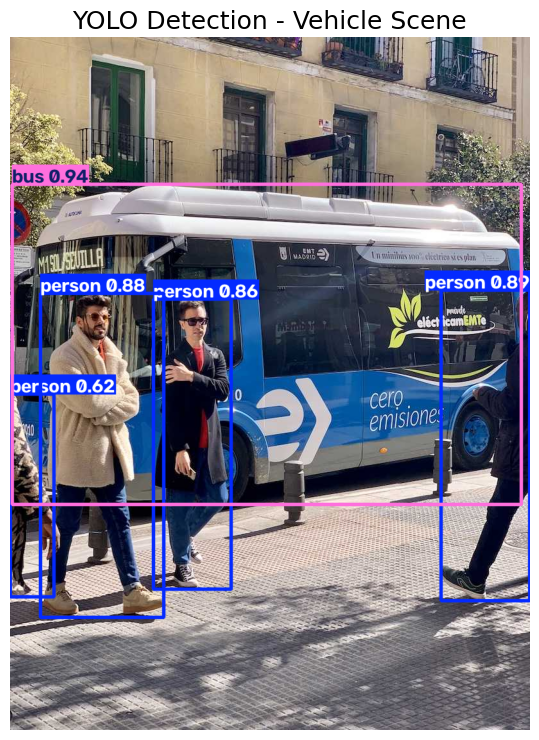

bus                 Confidence: 0.940
person              Confidence: 0.888
person              Confidence: 0.878
person              Confidence: 0.856
person              Confidence: 0.622

Vehicle detection results:


,Object,Confidence
0,bus,0.940152
1,person,0.888220
2,person,0.878255
3,person,0.855773
4,person,0.621919



Inference time: 0.0626 seconds
Approximate FPS: 15.97

Saved: /content/YOLO-Autonomous-Vehicle/output/vehicle_detection.jpg
Saved: /content/YOLO-Autonomous-Vehicle/results/vehicle_detection_results.csv


In [5]:
# ================================================================
# REPLACE TEST IMAGE WITH AN AUTONOMOUS-VEHICLE-RELEVANT SCENE
# ================================================================

import urllib.request
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Official Ultralytics sample image
url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg"

vehicle_image = Path(
    "/content/YOLO-Autonomous-Vehicle/input/vehicle_scene.jpg"
)

print("Downloading vehicle scene...")

try:
    urllib.request.urlretrieve(
        url,
        str(vehicle_image)
    )

    img = cv2.imread(
        str(vehicle_image)
    )

    if img is None:
        raise RuntimeError("Downloaded file is not a valid image.")

    print("Vehicle scene downloaded successfully.")
    print("Image shape:", img.shape)

except Exception as e:

    print("Download failed:", e)
    raise


# ------------------------------------------------
# RUN YOLO
# ------------------------------------------------

print("\nRunning YOLO on vehicle scene...")

start = time.perf_counter()

vehicle_results = model.predict(
    source=str(vehicle_image),
    device=DEVICE,
    imgsz=640,
    conf=0.25,
    verbose=False
)

end = time.perf_counter()

vehicle_time = end - start

vehicle_result = vehicle_results[0]

vehicle_annotated = vehicle_result.plot()


# ------------------------------------------------
# SAVE RESULT
# ------------------------------------------------

vehicle_output = Path(
    "/content/YOLO-Autonomous-Vehicle/output/"
    "vehicle_detection.jpg"
)

cv2.imwrite(
    str(vehicle_output),
    vehicle_annotated
)


# ------------------------------------------------
# DISPLAY
# ------------------------------------------------

plt.figure(
    figsize=(14, 9)
)

plt.imshow(
    cv2.cvtColor(
        vehicle_annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "YOLO Detection - Vehicle Scene",
    fontsize=18
)

plt.axis("off")

plt.show()


# ------------------------------------------------
# EXTRACT DETECTIONS
# ------------------------------------------------

vehicle_detections = []

if vehicle_result.boxes is not None:

    for i in range(
        len(vehicle_result.boxes)
    ):

        class_id = int(
            vehicle_result.boxes.cls[i].item()
        )

        confidence = float(
            vehicle_result.boxes.conf[i].item()
        )

        object_name = model.names[
            class_id
        ]

        vehicle_detections.append({
            "Object": object_name,
            "Confidence": confidence
        })

        print(
            f"{object_name:<20}"
            f"Confidence: {confidence:.3f}"
        )


# ------------------------------------------------
# SAVE CSV
# ------------------------------------------------

vehicle_df = pd.DataFrame(
    vehicle_detections
)

vehicle_csv = Path(
    "/content/YOLO-Autonomous-Vehicle/"
    "results/vehicle_detection_results.csv"
)

vehicle_df.to_csv(
    str(vehicle_csv),
    index=False
)

print("\nVehicle detection results:")
display(vehicle_df)

print(
    f"\nInference time: {vehicle_time:.4f} seconds"
)

print(
    f"Approximate FPS: {1 / vehicle_time:.2f}"
)

print(
    "\nSaved:",
    vehicle_output
)

print(
    "Saved:",
    vehicle_csv
)

In [7]:
# ============================================================
# FINAL YOLO PROJECT CLEANUP + GITHUB PACKAGE
# SAFE VERSION
# ============================================================

from pathlib import Path
import shutil
import zipfile
import os
import pandas as pd

# ------------------------------------------------------------
# 1. PROJECT PATHS
# ------------------------------------------------------------

PROJECT = Path("/content/YOLO-Autonomous-Vehicle")

SRC = PROJECT / "src"
INPUT = PROJECT / "input"
OUTPUT = PROJECT / "output"
RESULTS = PROJECT / "results"
GRAPHS = RESULTS / "graphs"
REPORT = PROJECT / "report"

for folder in [SRC, INPUT, OUTPUT, RESULTS, GRAPHS, REPORT]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project found:", PROJECT)

# ------------------------------------------------------------
# 2. CLEAN OLD MISLEADING FILES
# ------------------------------------------------------------

files_to_remove = [
    INPUT / "sample_vehicle_scene.jpg",
    INPUT / "zidane.jpg",
    OUTPUT / "detected_objects.jpg",
    OUTPUT / "zidane_detection.jpg",
    RESULTS / "detection_results.csv",
]

for file in files_to_remove:
    if file.exists():
        file.unlink()
        print("Removed:", file.name)

# ------------------------------------------------------------
# 3. CHECK VEHICLE DETECTION RESULT
# ------------------------------------------------------------

vehicle_image = OUTPUT / "vehicle_detection.jpg"
vehicle_csv = RESULTS / "vehicle_detection_results.csv"

print("\nChecking experiment results...")

if vehicle_image.exists():
    print("OK - vehicle_detection.jpg")
else:
    print("WARNING - vehicle_detection.jpg not found")

if vehicle_csv.exists():
    print("OK - vehicle_detection_results.csv")
else:
    print("WARNING - vehicle_detection_results.csv not found")

# ------------------------------------------------------------
# 4. EXPERIMENT SUMMARY CSV
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Model Variant",
        "Platform",
        "GPU",
        "Framework",
        "Ultralytics Version",
        "PyTorch Version",
        "Test Scene",
        "Single Inference Time (seconds)",
        "Single Inference FPS",
        "Benchmark Runs",
        "Average Inference Time (seconds)",
        "Minimum Inference Time (seconds)",
        "Maximum Inference Time (seconds)",
        "Standard Deviation (seconds)",
        "Average Benchmark FPS"
    ],
    "Value": [
        "YOLO",
        "YOLO11n",
        "Google Colab",
        "NVIDIA Tesla T4",
        "Ultralytics",
        "8.4.164",
        "2.11.0+cu128",
        "Urban bus / vehicle scene",
        "0.0626",
        "15.97",
        "20",
        "0.0202",
        "0.0184",
        "0.0249",
        "0.0016",
        "49.53"
    ]
})

summary.to_csv(
    RESULTS / "experiment_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 5. TEXT SUMMARY
# ------------------------------------------------------------

summary_text = "\n".join([
    "YOLO AUTONOMOUS VEHICLE OBJECT DETECTION",
    "=========================================",
    "",
    "Model: YOLO11n",
    "Platform: Google Colab",
    "GPU: NVIDIA Tesla T4",
    "Framework: Ultralytics 8.4.164",
    "PyTorch: 2.11.0+cu128",
    "Test Scene: Urban bus / vehicle scene",
    "",
    "Detected objects:",
    "- Bus",
    "- Person",
    "- Person",
    "- Person",
    "- Person",
    "",
    "Latest single inference:",
    "Inference time: 0.0626 seconds",
    "Approximate FPS: 15.97",
    "",
    "20-run benchmark:",
    "Average inference time: 0.0202 seconds",
    "Minimum inference time: 0.0184 seconds",
    "Maximum inference time: 0.0249 seconds",
    "Standard deviation: 0.0016 seconds",
    "Approximate average FPS: 49.53",
    "",
    "Important limitation:",
    "The measured FPS depends on the Google Colab runtime and NVIDIA",
    "Tesla T4 GPU. It should not be interpreted as guaranteed",
    "production autonomous-vehicle performance.",
    "",
    "A complete AV evaluation would require a larger labeled dataset",
    "and metrics such as precision, recall and mAP."
])

with open(
    RESULTS / "experiment_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

# ------------------------------------------------------------
# 6. CREATE detect_image.py
# ------------------------------------------------------------

detect_image_code = "\n".join([
    'from ultralytics import YOLO',
    'from pathlib import Path',
    'import pandas as pd',
    'import time',
    'import cv2',
    '',
    'PROJECT_ROOT = Path(__file__).resolve().parent.parent',
    'INPUT_DIR = PROJECT_ROOT / "input"',
    'OUTPUT_DIR = PROJECT_ROOT / "output"',
    'RESULTS_DIR = PROJECT_ROOT / "results"',
    '',
    'OUTPUT_DIR.mkdir(exist_ok=True)',
    'RESULTS_DIR.mkdir(exist_ok=True)',
    '',
    'IMAGE_PATH = INPUT_DIR / "vehicle_scene.jpg"',
    'OUTPUT_PATH = OUTPUT_DIR / "vehicle_detection.jpg"',
    'CSV_PATH = RESULTS_DIR / "vehicle_detection_results.csv"',
    '',
    'model = YOLO("yolo11n.pt")',
    '',
    'start = time.time()',
    'results = model(str(IMAGE_PATH), conf=0.25)',
    'elapsed = time.time() - start',
    '',
    'annotated = results[0].plot()',
    'cv2.imwrite(str(OUTPUT_PATH), annotated)',
    '',
    'detections = []',
    '',
    'for result in results:',
    '    if result.boxes is not None:',
    '        for box in result.boxes:',
    '            class_id = int(box.cls[0])',
    '            confidence = float(box.conf[0])',
    '',
    '            detections.append({',
    '                "Object": model.names[class_id],',
    '                "Confidence": confidence',
    '            })',
    '',
    'df = pd.DataFrame(detections)',
    'df.to_csv(CSV_PATH, index=False)',
    '',
    'print("YOLO Autonomous Vehicle Detection")',
    'print("---------------------------------")',
    'print("Model: YOLO11n")',
    'print(f"Inference time: {elapsed:.4f} seconds")',
    'print(f"Approximate FPS: {1 / elapsed:.2f}")',
    '',
    'print("\\nDetections:")',
    'print(df.to_string(index=False))',
    '',
    'print(f"\\nAnnotated image saved to: {OUTPUT_PATH}")',
    'print(f"Detection CSV saved to: {CSV_PATH}")'
])

with open(
    SRC / "detect_image.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(detect_image_code)

# ------------------------------------------------------------
# 7. CREATE PERFORMANCE SCRIPT
# ------------------------------------------------------------

performance_code = "\n".join([
    'from ultralytics import YOLO',
    'import time',
    'import statistics',
    '',
    'IMAGE_PATH = "../input/vehicle_scene.jpg"',
    'model = YOLO("yolo11n.pt")',
    '',
    'NUM_RUNS = 20',
    'times = []',
    '',
    'print(f"Running {NUM_RUNS} inference tests...")',
    '',
    '# Warm-up',
    'model(IMAGE_PATH, verbose=False)',
    '',
    'for i in range(NUM_RUNS):',
    '    start = time.time()',
    '    model(IMAGE_PATH, verbose=False)',
    '    elapsed = time.time() - start',
    '    times.append(elapsed)',
    '',
    'average_time = statistics.mean(times)',
    'minimum_time = min(times)',
    'maximum_time = max(times)',
    'std_time = statistics.stdev(times)',
    'fps = 1 / average_time',
    '',
    'print("\\nYOLO11n Performance")',
    'print("-------------------")',
    'print(f"Average inference time : {average_time:.4f} sec")',
    'print(f"Minimum inference time : {minimum_time:.4f} sec")',
    'print(f"Maximum inference time : {maximum_time:.4f} sec")',
    'print(f"Standard deviation     : {std_time:.4f} sec")',
    'print(f"Approximate FPS        : {fps:.2f}")'
])

with open(
    SRC / "performance_analysis.py",
    "w",
    encoding="utf-8"
) as f:
    f.write(performance_code)

# ------------------------------------------------------------
# 8. REQUIREMENTS.TXT
# ------------------------------------------------------------

requirements = "\n".join([
    "ultralytics==8.4.164",
    "opencv-python",
    "numpy",
    "pandas",
    "matplotlib",
    "pillow",
    "tqdm"
])

with open(
    PROJECT / "requirements.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements)

# ------------------------------------------------------------
# 9. .GITIGNORE
# ------------------------------------------------------------

gitignore = "\n".join([
    "__pycache__/",
    "*.py[cod]",
    "*.pyo",
    ".ipynb_checkpoints/",
    "venv/",
    "env/",
    ".venv/",
    "*.pt",
    "*.onnx",
    "*.tmp",
    "*.log",
    ".config/",
    ".DS_Store"
])

with open(
    PROJECT / ".gitignore",
    "w",
    encoding="utf-8"
) as f:
    f.write(gitignore)

# ------------------------------------------------------------
# 10. README
# ------------------------------------------------------------

readme_lines = [
    "# YOLO Autonomous Vehicle Object Detection",
    "",
    "## Analysis of Real-Time Object Detection Using YOLO",
    "",
    "This project implements YOLO11n object detection for an",
    "autonomous-vehicle perception scenario.",
    "",
    "The system processes an urban vehicle scene and detects objects",
    "such as buses and pedestrians. It also measures inference time",
    "and approximate frames per second (FPS).",
    "",
    "## Objectives",
    "",
    "- Implement YOLO-based object detection.",
    "- Detect road-scene objects relevant to autonomous vehicles.",
    "- Draw bounding boxes and confidence scores.",
    "- Store detection results in CSV format.",
    "- Measure inference speed.",
    "- Analyze suitability for real-time perception.",
    "",
    "## Technology Stack",
    "",
    "- Python",
    "- Ultralytics YOLO",
    "- YOLO11n",
    "- OpenCV",
    "- NumPy",
    "- Pandas",
    "- Matplotlib",
    "- Google Colab",
    "- NVIDIA Tesla T4",
    "",
    "## System Pipeline",
    "",
    "Input Image -> Preprocessing -> YOLO11n ->",
    "Object Classes + Confidence -> Annotated Image ->",
    "Performance Analysis",
    "",
    "## Experimental Results",
    "",
    "The vehicle scene produced detections including a bus and",
    "multiple pedestrians.",
    "",
    "The highest-confidence bus detection had approximately",
    "0.94 confidence.",
    "",
    "## Performance Results",
    "",
    "| Metric | Result |",
    "|---|---:|",
    "| Model | YOLO11n |",
    "| GPU | NVIDIA Tesla T4 |",
    "| Single inference time | 0.0626 s |",
    "| Single-run FPS | 15.97 |",
    "| Benchmark runs | 20 |",
    "| Average inference time | 0.0202 s |",
    "| Minimum inference time | 0.0184 s |",
    "| Maximum inference time | 0.0249 s |",
    "| Standard deviation | 0.0016 s |",
    "| Average benchmark FPS | 49.53 |",
    "",
    "## Important Limitation",
    "",
    "The measured FPS depends on the Google Colab runtime and",
    "NVIDIA Tesla T4 GPU. It is not a guaranteed production",
    "autonomous-vehicle frame rate.",
    "",
    "A complete AV benchmark would require a larger labeled dataset",
    "and metrics such as precision, recall and mAP.",
    "",
    "## Project Structure",
    "",
    "```text",
    "YOLO-Autonomous-Vehicle/",
    "|",
    "|-- README.md",
    "|-- requirements.txt",
    "|-- .gitignore",
    "|-- model_comparison.md",
    "|-- COLAB_INSTRUCTIONS.md",
    "|-- YOLO_Autonomous_Vehicle_Project.ipynb",
    "|",
    "|-- src/",
    "|   |-- detect_image.py",
    "|   |-- performance_analysis.py",
    "|",
    "|-- input/",
    "|   |-- vehicle_scene.jpg",
    "|",
    "|-- output/",
    "|   |-- vehicle_detection.jpg",
    "|",
    "|-- results/",
    "|   |-- vehicle_detection_results.csv",
    "|   |-- experiment_summary.csv",
    "|   |-- experiment_summary.txt",
    "|   |-- graphs/",
    "|",
    "|-- report/",
    "|   |-- Project_Report.pdf",
    "```",
    "",
    "## Running the Project",
    "",
    "Install dependencies:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "```",
    "",
    "Run:",
    "",
    "```bash",
    "python src/detect_image.py",
    "```",
    "",
    "The YOLO model weights are downloaded automatically.",
    "",
    "## Notebook",
    "",
    "The complete experimental workflow is provided in",
    "YOLO_Autonomous_Vehicle_Project.ipynb.",
    "",
    "## Conclusion",
    "",
    "The project demonstrates YOLO11n object detection in an urban",
    "vehicle scene and evaluates inference speed. The experiment",
    "successfully detected buses and pedestrians while providing",
    "measurable inference performance."
]

with open(
    PROJECT / "README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(readme_lines))

# ------------------------------------------------------------
# 11. MODEL COMPARISON NOTES
# ------------------------------------------------------------

comparison_lines = [
    "# YOLO vs SSD vs Faster R-CNN",
    "",
    "The assignment discusses YOLO, SSD and Faster R-CNN.",
    "",
    "This project experimentally implements YOLO11n.",
    "",
    "| Model | Architecture | General characteristic |",
    "|---|---|---|",
    "| YOLO | One-stage detector | Designed for fast end-to-end detection |",
    "| SSD | One-stage detector | Efficient object detection approach |",
    "| Faster R-CNN | Two-stage detector | Region-based detection approach |",
    "",
    "This repository does not claim measured SSD or Faster R-CNN",
    "performance.",
    "",
    "A fair numerical comparison would require all models to run",
    "on the same dataset and hardware using common metrics such",
    "as mAP, precision, recall, latency and FPS."
]

with open(
    PROJECT / "model_comparison.md",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(comparison_lines))

# ------------------------------------------------------------
# 12. COLAB INSTRUCTIONS
# ------------------------------------------------------------

colab_lines = [
    "# Google Colab Instructions",
    "",
    "1. Open YOLO_Autonomous_Vehicle_Project.ipynb.",
    "2. Open it in Google Colab.",
    "3. Select Runtime -> Change runtime type.",
    "4. Select a GPU if available.",
    "5. Run the notebook from top to bottom.",
    "6. YOLO11n weights are downloaded automatically.",
    "7. Detection results are saved in output/.",
    "8. CSV and performance results are saved in results/."
]

with open(
    PROJECT / "COLAB_INSTRUCTIONS.md",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(colab_lines))

# ------------------------------------------------------------
# 13. REPORT README
# ------------------------------------------------------------

report_lines = [
    "# Project Report",
    "",
    "The final PDF report will be placed here as:",
    "",
    "Project_Report.pdf",
    "",
    "The report will contain:",
    "",
    "1. Abstract",
    "2. Introduction",
    "3. Problem Statement",
    "4. Objectives",
    "5. YOLO Background",
    "6. Methodology",
    "7. System Architecture",
    "8. Experimental Setup",
    "9. Detection Results",
    "10. Performance Analysis",
    "11. YOLO vs SSD vs Faster R-CNN Discussion",
    "12. Limitations",
    "13. Future Scope",
    "14. Conclusion",
    "15. References"
]

with open(
    REPORT / "README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write("\n".join(report_lines))

# ------------------------------------------------------------
# 14. FINAL FILE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL PROJECT FILE CHECK")
print("=" * 65)

important_files = [
    PROJECT / "README.md",
    PROJECT / "requirements.txt",
    PROJECT / ".gitignore",
    PROJECT / "model_comparison.md",
    PROJECT / "COLAB_INSTRUCTIONS.md",
    SRC / "detect_image.py",
    SRC / "performance_analysis.py",
    OUTPUT / "vehicle_detection.jpg",
    RESULTS / "vehicle_detection_results.csv",
    RESULTS / "experiment_summary.csv",
    RESULTS / "experiment_summary.txt"
]

for file in important_files:
    if file.exists():
        print("[OK]     ", file.relative_to(PROJECT))
    else:
        print("[MISSING]", file.relative_to(PROJECT))

# ------------------------------------------------------------
# 15. SHOW PROJECT STRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PROJECT STRUCTURE")
print("=" * 65)

for root, dirs, files in os.walk(PROJECT):

    dirs[:] = [
        d for d in dirs
        if d not in ["__pycache__", ".ipynb_checkpoints", ".config"]
    ]

    relative = Path(root).relative_to(PROJECT)

    level = len(relative.parts)

    if level == 0:
        print("YOLO-Autonomous-Vehicle/")
    else:
        print("    " * level + Path(root).name + "/")

    for file in sorted(files):

        # Do not display model weights
        if file.endswith(".pt"):
            continue

        print("    " * (level + 1) + file)

# ------------------------------------------------------------
# 16. CREATE GITHUB ZIP
# ------------------------------------------------------------

zip_path = Path("/content/YOLO-Autonomous-Vehicle-GitHub.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(PROJECT):

        dirs[:] = [
            d for d in dirs
            if d not in [
                "__pycache__",
                ".ipynb_checkpoints",
                ".config"
            ]
        ]

        for file in files:

            # Never include model weights
            if file.endswith(".pt"):
                continue

            full_path = Path(root) / file

            relative_path = full_path.relative_to(PROJECT.parent)

            zipf.write(
                full_path,
                relative_path
            )

# ------------------------------------------------------------
# 17. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SUCCESS!")
print("=" * 65)

print("\nGitHub-ready ZIP:")
print(zip_path)

print("\nProject folder:")
print(PROJECT)

print("\nNEXT:")
print("1. Download the GitHub ZIP.")
print("2. Download the Colab notebook as .ipynb.")
print("3. Create the GitHub repository.")
print("4. Upload the extracted project files.")
print("5. Upload the .ipynb.")
print("6. We will create the final PDF report.")

Project found: /content/YOLO-Autonomous-Vehicle
Removed: sample_vehicle_scene.jpg
Removed: detected_objects.jpg
Removed: detection_results.csv

Checking experiment results...
OK - vehicle_detection.jpg
OK - vehicle_detection_results.csv

FINAL PROJECT FILE CHECK
[OK]      README.md
[OK]      requirements.txt
[OK]      .gitignore
[OK]      model_comparison.md
[OK]      COLAB_INSTRUCTIONS.md
[OK]      src/detect_image.py
[OK]      src/performance_analysis.py
[OK]      output/vehicle_detection.jpg
[OK]      results/vehicle_detection_results.csv
[OK]      results/experiment_summary.csv
[OK]      results/experiment_summary.txt

PROJECT STRUCTURE
YOLO-Autonomous-Vehicle/
    .gitignore
    COLAB_INSTRUCTIONS.md
    README.md
    model_comparison.md
    requirements.txt
    src/
        detect_image.py
        performance_analysis.py
    report/
        README.md
    results/
        experiment_summary.csv
        experiment_summary.txt
        performance_results.csv
        performance_summ